In [1]:
# Reload the TSV files while ignoring metadata/comment lines.
from pathlib import Path

import pandas as pd

data_dir = Path("data")

tables = {}

for path in sorted(data_dir.glob("*.tsv")):
    table = pd.read_csv(
        path,
        sep="\t",
        comment="#",
        encoding="utf-8",
        on_bad_lines="skip",
    )
    table.columns = table.columns.astype(str).str.strip()
    tables[path.stem] = table

    print(f"{path.name}: {table.shape}")
    display(table.head())

# Convenient references for exploration
df = tables.get("week1_nodes", next(iter(tables.values())))
edges = tables.get("week1_edges")

print("Available tables:", list(tables))
print("\nSelected dataframe columns:")
display(df.columns.to_frame(index=False, name="column"))

print("\nSummary:")
display(df.describe(include="all").T)

if edges is not None:
    print("\nEdges:")
    display(edges.head())

week1_edges.tsv: (1783, 2)


,Abomination_(character),Deathlok
0,Abomination_(character),Gargoyle_(comics)
1,Abomination_(character),Hercules_(Marvel_Comics)
2,Abomination_(character),Hulk
3,Abomination_(character),Jessica_Jones
4,Abomination_(character),Kristoff_Vernard


week1_nodes.tsv: (303, 5)


,node_id,name,wikidata_id,url,description
0,Abomination_(character),Abomination (character),Q60146,https://en.wikipedia.org/wiki/Abomination_(cha...,The Abomination (Emil Blonsky) is a character ...
1,Adam_Warlock,Adam Warlock,Q1735229,https://en.wikipedia.org/wiki/Adam_Warlock,Adam Warlock is a character appearing in Ameri...
2,Agent_X_(Marvel_Comics),Agent X (Marvel Comics),Q1054789,https://en.wikipedia.org/wiki/Agent_X_(Marvel_...,"Agent X (Nijo Minamiyori, alias Alex Hayden) i..."
3,Ajak,Ajak,Q554230,https://en.wikipedia.org/wiki/Ajak,Ajak is a fictional character appearing in Ame...
4,Alex_Wilder,Alex Wilder,Q3610734,https://en.wikipedia.org/wiki/Alex_Wilder,Alex Wilder is a fictional character appearing...


Available tables: ['week1_edges', 'week1_nodes']

Selected dataframe columns:


,column
0,node_id
1,name
2,wikidata_id
3,url
4,description



Summary:


,count,unique,top,freq
node_id,303,303,Abomination_(character),1
name,303,303,Abomination (character),1
wikidata_id,303,303,Q60146,1
url,303,303,https://en.wikipedia.org/wiki/Abomination_(cha...,1
description,303,303,The Abomination (Emil Blonsky) is a character ...,1



Edges:


,Abomination_(character),Deathlok
0,Abomination_(character),Gargoyle_(comics)
1,Abomination_(character),Hercules_(Marvel_Comics)
2,Abomination_(character),Hulk
3,Abomination_(character),Jessica_Jones
4,Abomination_(character),Kristoff_Vernard


In [2]:
import pandas as pd, networkx as nx

nodes = pd.read_csv("data/week1_nodes.tsv", sep="\t", comment="#",
                    quoting=3)  # QUOTE_NONE: TSVs never quote, but blurbs may contain "quotes"
edges = pd.read_csv("data/week1_edges.tsv", sep="\t", comment="#",
                    names=["source", "target"])

G = nx.DiGraph()
G.add_nodes_from(nodes.node_id)
G.add_edges_from(edges.itertuples(index=False))
#G: 303 nodes, 1784 edges

In [3]:
print(G)

DiGraph with 303 nodes and 1784 edges


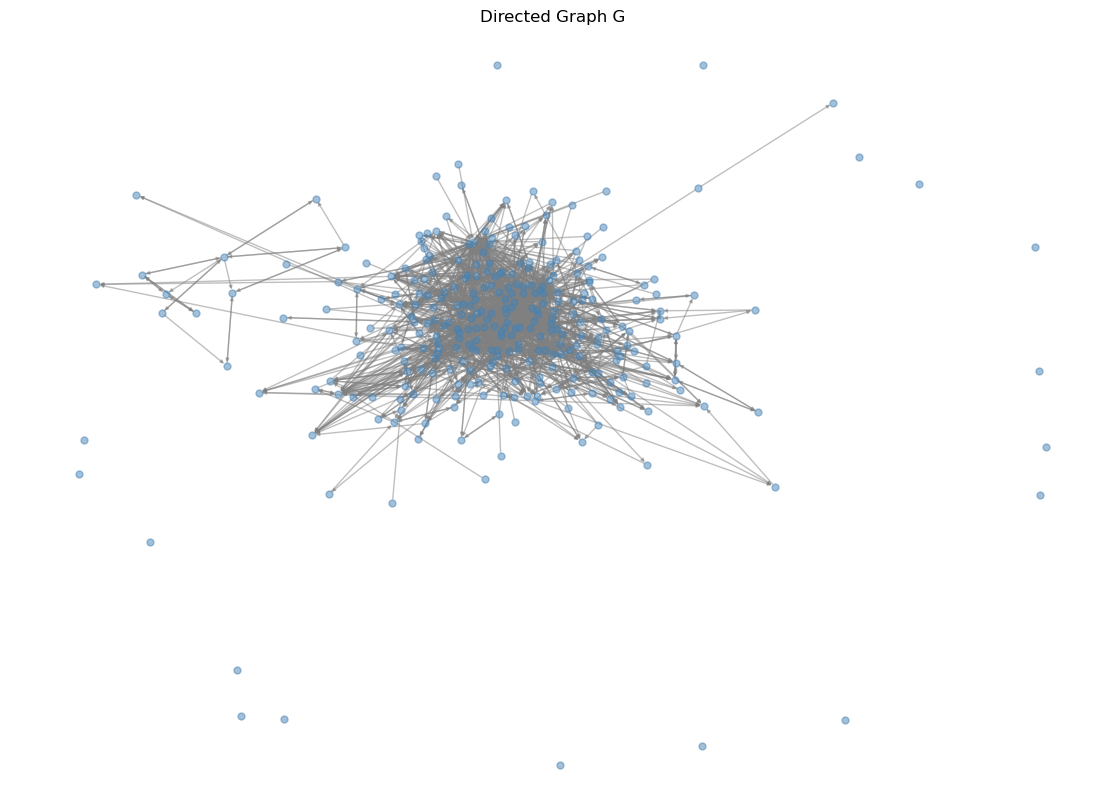

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.15)

nx.draw_networkx(
    G,
    pos=pos,
    node_size=25,
    node_color="steelblue",
    edge_color="gray",
    alpha=0.5,
    arrows=True,
    with_labels=False,
    arrowsize=5,
)

plt.title("Directed Graph G")
plt.axis("off")
plt.show()

In [6]:
# One row per character, including the 17 isolates.
degree_table = pd.DataFrame({
    "node_id": list(G.nodes),
    "in_degree": [G.in_degree(node) for node in G.nodes],
    "out_degree": [G.out_degree(node) for node in G.nodes],
})
degree_table = degree_table.merge(nodes[["node_id", "name"]], on="node_id", how="left")
degree_table["total_degree"] = degree_table["in_degree"] + degree_table["out_degree"]

print(f"Characters: {len(degree_table):,}; directed links: {G.number_of_edges():,}")
display(degree_table.describe().T)

Characters: 303; directed links: 1,784


,count,mean,std,min,25%,50%,75%,max
in_degree,303.0,5.887789,9.990423,0.0,1.0,3.0,7.0,106.0
out_degree,303.0,5.887789,5.056693,0.0,2.0,4.0,8.5,28.0
total_degree,303.0,11.775578,13.249108,0.0,4.0,7.0,15.5,115.0


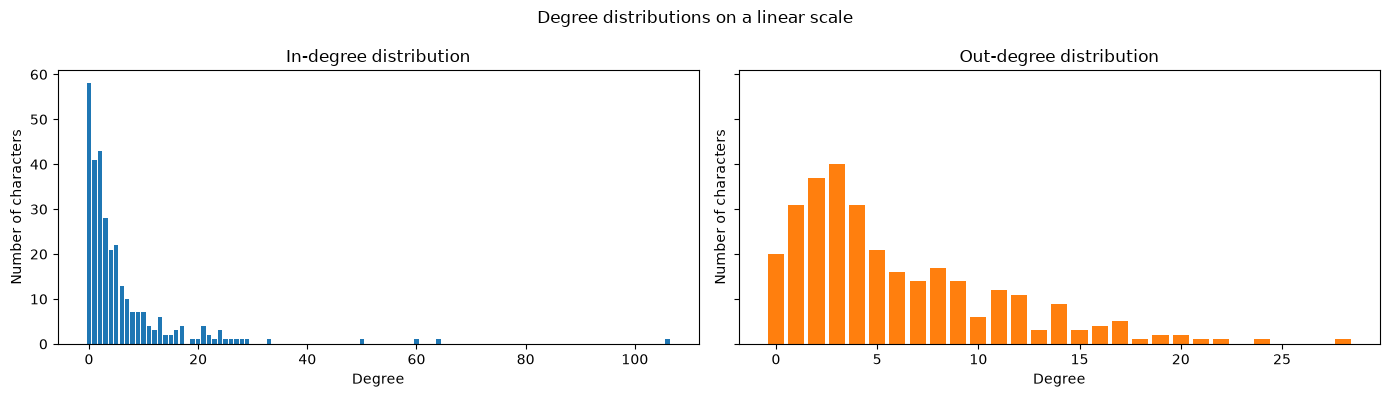

In [7]:
# Linear-scale degree distributions: how many characters have each degree?
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, column, title, color in [
    (axes[0], "in_degree", "In-degree distribution", "tab:blue"),
    (axes[1], "out_degree", "Out-degree distribution", "tab:orange"),
]:
    frequency = degree_table[column].value_counts().sort_index()
    ax.bar(frequency.index, frequency.values, color=color, width=0.8)
    ax.set(title=title, xlabel="Degree", ylabel="Number of characters")

fig.suptitle("Degree distributions on a linear scale")
plt.tight_layout()
plt.show()

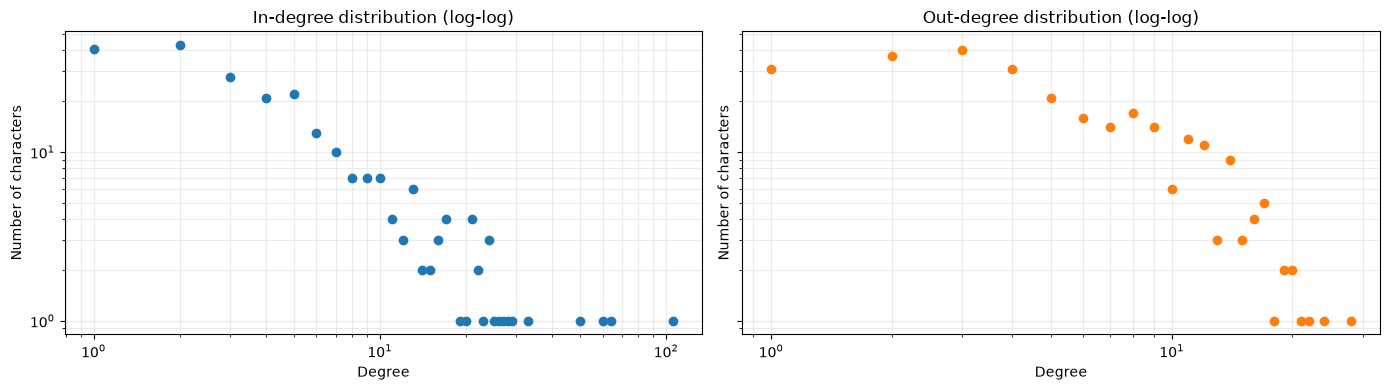

In [8]:
# The same distributions on log-log axes reveal the long tail more clearly.
# Degree zero is omitted because log(0) is undefined.
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, column, title, color in [
    (axes[0], "in_degree", "In-degree distribution (log-log)", "tab:blue"),
    (axes[1], "out_degree", "Out-degree distribution (log-log)", "tab:orange"),
]:
    frequency = degree_table[column].value_counts().sort_index()
    positive = frequency[frequency.index > 0]
    ax.loglog(positive.index, positive.values, "o", color=color)
    ax.set(title=title, xlabel="Degree", ylabel="Number of characters")
    ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

In [9]:
# These are the characters whose articles are linked *to* most often.
top_in = degree_table.sort_values(["in_degree", "name"], ascending=[False, True]).tail(15)
display(top_in[["name", "in_degree", "out_degree", "total_degree"]].reset_index(drop=True))

,name,in_degree,out_degree,total_degree
0,Sean and Chris,0,0,0
1,Shamrock (comics),0,8,8
2,Silencer (comics),0,2,2
3,Silhouette (comics),0,2,2
4,Solarman,0,0,0
5,Solomon Kane (comics),0,1,1
6,Spider-Man (Marvel Mangaverse),0,3,3
7,Straw Man (comics),0,2,2
8,Super Rabbit,0,0,0
9,Thunderbolt (Marvel Comics),0,2,2


In [10]:
# These are the characters whose articles link *out* to the most other heroes.
top_out = degree_table.sort_values(["out_degree", "name"], ascending=[False, True]).head(15)
display(top_out[["name", "out_degree", "in_degree", "total_degree"]].reset_index(drop=True))

,name,out_degree,in_degree,total_degree
0,Betsy Braddock,28,7,35
1,Cloak and Dagger (characters),24,11,35
2,Adam Warlock,22,8,30
3,Venom (character),21,17,38
4,She-Hulk,20,29,49
5,U.S. Agent,20,6,26
6,Deadpool,19,33,52
7,Rachel Summers,19,16,35
8,Noh-Varr,18,4,22
9,Doctor Strange,17,50,67


### Why the two rankings differ

In-degree measures a character's **visibility in other characters' articles**: a high value suggests that many biographies mention that character. Out-degree measures the **breadth of links written into that character's own article**: a high value can reflect a relationship-rich story, a long article, or editorial choices about which names to link. They are related but not interchangeable, and neither alone measures a character's narrative importance.

In [11]:
# Compare the leaders directly and look for characters that are especially more cited than citing (or vice versa).
comparison = pd.DataFrame({
    "most linked to": top_in["name"].to_list(),
    "in-degree": top_in["in_degree"].to_list(),
    "links out most": top_out["name"].to_list(),
    "out-degree": top_out["out_degree"].to_list(),
})

overlap = set(top_in["node_id"]) & set(top_out["node_id"])
print(f"Top-15 overlap: {len(overlap)} characters")
display(comparison)

degree_table["in_minus_out"] = degree_table["in_degree"] - degree_table["out_degree"]
print("Most cited relative to their own outgoing links:")
display(degree_table.nlargest(10, "in_minus_out")[["name", "in_degree", "out_degree", "in_minus_out"]].reset_index(drop=True))
print("Most outgoing-link-heavy relative to incoming links:")
display(degree_table.nsmallest(10, "in_minus_out")[["name", "in_degree", "out_degree", "in_minus_out"]].reset_index(drop=True))

Top-15 overlap: 0 characters


,most linked to,in-degree,links out most,out-degree
0,Sean and Chris,0,Betsy Braddock,28
1,Shamrock (comics),0,Cloak and Dagger (characters),24
2,Silencer (comics),0,Adam Warlock,22
3,Silhouette (comics),0,Venom (character),21
4,Solarman,0,She-Hulk,20
5,Solomon Kane (comics),0,U.S. Agent,20
6,Spider-Man (Marvel Mangaverse),0,Deadpool,19
7,Straw Man (comics),0,Rachel Summers,19
8,Super Rabbit,0,Noh-Varr,18
9,Thunderbolt (Marvel Comics),0,Doctor Strange,17


Most cited relative to their own outgoing links:


,name,in_degree,out_degree,in_minus_out
0,Spider-Man,106,9,97
1,Hulk,64,10,54
2,Wolverine (character),60,17,43
3,Doctor Strange,50,17,33
4,Quasar (character),24,3,21
5,Black Panther (character),27,11,16
6,Hank Pym,24,8,16
7,Luke Cage,25,9,16
8,Black Widow (Natasha Romanova),22,7,15
9,Cyclops (Marvel Comics),26,11,15


Most outgoing-link-heavy relative to incoming links:


,name,in_degree,out_degree,in_minus_out
0,Betsy Braddock,7,28,-21
1,Adam Warlock,8,22,-14
2,Noh-Varr,4,18,-14
3,U.S. Agent,6,20,-14
4,Cloak and Dagger (characters),11,24,-13
5,Spider-Bitch (Ashley Barton),2,15,-13
6,Solo (Marvel Comics),1,12,-11
7,Brian Braddock,1,11,-10
8,Firebird (Marvel Comics),2,12,-10
9,Northstar (character),4,14,-10
